In [2]:
import re
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

2026-02-26 17:14:36.375786: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-26 17:14:37.889673: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [3]:
def labels_to_dataframe_verified(file_path, image_dir):
    with open(file_path, 'r') as f:
        content = f.read()

    # Pattern captures the image name and exactly 4 attributes
    pattern = r'(image_\d+\.jpg)\s+(1|0|NA)\s+(1|0|NA)\s+(1|0|NA)\s+(1|0|NA)'
    matches = re.findall(pattern, content)
    
    verified_data = []
    missing_count = 0

    for match in matches:
        img_name = match[0]
        # Construct the full path to check the directory
        full_path = os.path.join(image_dir, img_name)
        
        # Only add to the list if the image actually exists on disk
        if os.path.exists(full_path):
            verified_data.append(match)
        else:
            missing_count += 1

    # Create the DataFrame from only verified rows
    df = pd.DataFrame(verified_data, columns=[
        'image_name', 
        'attribute_1', 
        'attribute_2', 
        'attribute_3', 
        'attribute_4'
    ])

    print(f"Total processed: {len(matches)}")
    print(f"Verified & Added: {len(df)}")
    print(f"Skipped (File not found): {missing_count}")
    
    return df

In [4]:
def load_and_preprocess_image(path, label, mask):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [224, 224])
    image = image / 255.0  # Normalization
    # Combine labels and masks so y_true is a single tensor (batch, 8)
    y_true = tf.concat([label, mask], axis=-1)
    return image, y_true

In [5]:
def get_dataset(text_file_path, img_dir, batch_size=32):
    df = labels_to_dataframe_verified(text_file_path , img_dir)

    df_filled = df.fillna(-1).replace('NA', -1)  # Replace 'NA'
    
    img_paths = [f"{img_dir}/{name}" for name in df_filled.iloc[:, 0]]
    labels = df_filled.iloc[:, 1:5].values.astype(np.float32)
    
    # Create masks: 1 if label is not -1, else 0
    masks = (labels != -1).astype(np.float32)
    # Clean labels: set -1 to 0 
    labels = np.where(labels == -1, 0, labels)
    
    # Create the base dataset
    ds = tf.data.Dataset.from_tensor_slices((img_paths, labels, masks))

    dataset_size = len(img_paths)
    
    ds = ds.shuffle(buffer_size=dataset_size, seed=42)
    train_size = int(0.8 * dataset_size)
    val_size = int(0.1 * dataset_size)
    
    train_ds = ds.take(train_size)
    remaining_ds = ds.skip(train_size)
    val_ds = remaining_ds.take(val_size)
    test_ds = remaining_ds.skip(val_size)
    
    train_ds = train_ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    val_ds = val_ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    test_ds = test_ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    
    return train_ds, val_ds, test_ds

In [6]:
def masked_bce_loss(y_true_combined, y_pred):
    # y_true_combined shape: (batch_size, 8) -> [labels(4), masks(4)]
    y_true = y_true_combined[:, :4]
    mask = y_true_combined[:, 4:]
    
    # Element-wise binary crossentropy (shape: batch, 4)
    bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)
    masked_loss = bce * mask
    
    # Avoid division by zero if a whole batch is masked
    denom = tf.reduce_sum(mask) + 1e-7
    return tf.reduce_sum(masked_loss) / denom

In [7]:
def build_model():
    base_model = tf.keras.applications.ResNet50V2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False # Fine-tuning: Freeze base first

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(4, activation='sigmoid') 
    ])
    
    model.compile(optimizer='adam', loss=masked_bce_loss)
    return model

25/25 [==============================] - 2s 62ms/step - loss: 0.0322 - val_loss: 0.0193
Epoch 47/50
25/25 [==============================] - 2s 63ms/step - loss: 0.0233 - val_loss: 0.0150
Epoch 48/50
25/25 [==============================] - 2s 62ms/step - loss: 0.0267 - val_loss: 0.0124
Epoch 49/50
25/25 [==============================] - 2s 63ms/step - loss: 0.0296 - val_loss: 0.0138
Epoch 50/50
25/25 [==============================] - 2s 63ms/step - loss: 0.0227 - val_loss: 0.0049


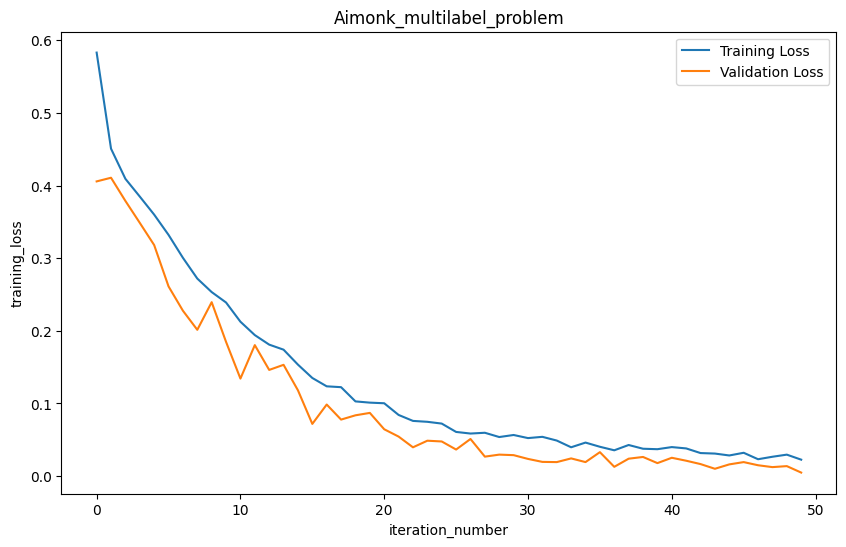

In [8]:
model = build_model()
train_dataset, validation_dataset, test_dataset  = get_dataset("Data/labels.txt", "Data/images/")

history = model.fit(
    train_dataset,
    validation_data=validation_dataset, 
    epochs=50
)

# Deliverable 2: Loss Curve Plot
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss') # The new validation line

plt.ylabel('training_loss')
plt.xlabel('iteration_number') 
plt.title('Aimonk_multilabel_problem')
plt.legend()
plt.savefig('loss_curve.png')
plt.show()

In [10]:
model.save("aimonk_model.h5")

/home/yash/.local/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [15]:
y_pred = model.predict(test_dataset)
y_pred_binary = (y_pred > 0.5).astype(int)
print("Predicted binary labels for the test set:")
print(y_pred_binary)

4/4 [==============================] - 1s 152ms/step
Predicted binary labels for the test set:
[[1 1 0 1]
 [1 1 1 0]
 [1 1 1 1]
 [1 1 0 0]
 [1 0 0 0]
 [1 1 1 0]
 [0 1 1 0]
 [1 1 0 1]
 [1 1 0 1]
 [1 1 0 0]
 [1 1 0 0]
 [1 0 0 0]
 [1 1 0 0]
 [1 1 1 0]
 [0 1 0 0]
 [1 1 1 0]
 [0 1 1 0]
 [1 1 1 0]
 [1 0 1 0]
 [1 1 0 0]
 [0 1 0 0]
 [0 1 1 0]
 [1 1 1 0]
 [1 1 0 0]
 [1 1 0 0]
 [1 1 1 0]
 [1 1 0 0]
 [1 1 0 0]
 [0 1 1 0]
 [1 1 1 0]
 [1 1 1 0]
 [1 1 1 0]
 [0 1 1 0]
 [1 1 0 0]
 [1 1 0 0]
 [1 1 0 0]
 [0 0 0 0]
 [1 1 0 0]
 [1 1 0 0]
 [1 1 1 0]
 [1 1 1 0]
 [1 1 1 0]
 [1 1 1 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 1 0 0]
 [1 1 0 0]
 [1 1 1 0]
 [1 0 1 0]
 [1 0 0 0]
 [1 1 0 0]
 [1 0 1 0]
 [1 1 0 0]
 [1 1 1 0]
 [1 1 1 0]
 [1 1 1 1]
 [0 1 0 0]
 [1 1 1 0]
 [1 1 1 0]
 [1 1 1 0]
 [1 1 0 0]
 [1 0 1 0]
 [1 1 0 0]
 [1 0 0 0]
 [1 0 1 1]
 [1 1 0 0]
 [1 1 1 1]
 [1 0 0 0]
 [1 1 1 0]
 [1 1 0 0]
 [1 1 0 0]
 [1 1 1 0]
 [0 1 1 0]
 [1 1 0 0]
 [1 1 1 0]
 [1 1 1 0]
 [1 1 1 0]
 [1 0 1 0]
 [1 1 1 0]
 [1 1 1 0]
 [1 1 1 0]
 [1

In [28]:
test_dataset
# This takes the first 1 batch from your dataset
for images, labels_and_masks in test_dataset.take(1):
    print("Batch Image Shape:", images.shape)
    print("Batch Label/Mask Shape:", labels_and_masks.shape)
    
    # To see the actual numbers for the first image in the batch
    print("First item labels and masks:")
    print(labels_and_masks.numpy()[:, :4])

Batch Image Shape: (32, 224, 224, 3)
Batch Label/Mask Shape: (32, 8)
First item labels and masks:
[[1. 0. 0. 0.]
 [1. 0. 1. 0.]
 [1. 1. 1. 0.]
 [1. 0. 0. 0.]
 [1. 1. 1. 0.]
 [1. 0. 1. 0.]
 [1. 0. 0. 1.]
 [1. 1. 1. 0.]
 [1. 1. 1. 0.]
 [0. 0. 1. 0.]
 [1. 1. 1. 0.]
 [1. 1. 1. 0.]
 [1. 1. 0. 0.]
 [0. 1. 1. 0.]
 [1. 1. 0. 1.]
 [1. 1. 1. 0.]
 [1. 1. 1. 0.]
 [1. 1. 1. 0.]
 [1. 0. 1. 1.]
 [1. 0. 0. 0.]
 [0. 1. 1. 0.]
 [1. 1. 0. 0.]
 [0. 0. 0. 0.]
 [1. 1. 0. 0.]
 [1. 0. 0. 0.]
 [1. 1. 1. 0.]
 [0. 1. 1. 1.]
 [1. 1. 0. 0.]
 [1. 0. 1. 0.]
 [1. 0. 1. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]]


In [31]:
from sklearn.model_selection import KFold

# Assuming 'df' is your verified DataFrame from labels_to_dataframe_verified()
df = labels_to_dataframe_verified("Data/labels.txt", "Data/images/")

img_paths = [f"Data/images/{name}" for name in df['image_name']]
labels = df[['attribute_1', 'attribute_2', 'attribute_3', 'attribute_4']].fillna(-1).replace('NA', -1).values.astype(np.float32)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_no = 1
all_histories = []

for train_index, val_index in kf.split(img_paths):
    print(f"--- Training Fold {fold_no} ---")
    
    # Split paths and labels for this fold
    train_paths = [img_paths[i] for i in train_index]
    val_paths = [img_paths[i] for i in val_index]
    
    train_labels_raw = labels[train_index]
    val_labels_raw = labels[val_index]
    
    # Generate masks and clean labels for this fold
    def prepare_fold_data(raw_labels):
        mask = (raw_labels != -1).astype(np.float32)
        clean_label = np.where(raw_labels == -1, 0, raw_labels)
        return clean_label, mask

    t_labels, t_masks = prepare_fold_data(train_labels_raw)
    v_labels, v_masks = prepare_fold_data(val_labels_raw)
    
    # Create TF Datasets
    train_ds = tf.data.Dataset.from_tensor_slices((train_paths, t_labels, t_masks))
    train_ds = train_ds.map(load_and_preprocess_image).batch(32).prefetch(tf.data.AUTOTUNE)
    
    val_ds = tf.data.Dataset.from_tensor_slices((val_paths, v_labels, v_masks))
    val_ds = val_ds.map(load_and_preprocess_image).batch(32).prefetch(tf.data.AUTOTUNE)
    
    # Build and Train
    model = build_model() # Your ResNet function
    history = model.fit(train_ds, validation_data=val_ds, epochs=10)
    
    all_histories.append(history.history['loss'])
    model.save_weights(f'model_fold_{fold_no}.h5')
    fold_no += 1

Total processed: 975
Verified & Added: 972
Skipped (File not found): 3
--- Training Fold 1 ---
Epoch 1/10
25/25 [==============================] - 5s 102ms/step - loss: 0.5692 - val_loss: 0.5023
Epoch 2/10
25/25 [==============================] - 2s 72ms/step - loss: 0.4242 - val_loss: 0.5080
Epoch 3/10
25/25 [==============================] - 2s 74ms/step - loss: 0.3908 - val_loss: 0.5163
Epoch 4/10
25/25 [==============================] - 2s 74ms/step - loss: 0.3546 - val_loss: 0.5481
Epoch 5/10
25/25 [==============================] - 2s 81ms/step - loss: 0.3169 - val_loss: 0.5534
Epoch 6/10
25/25 [==============================] - 3s 100ms/step - loss: 0.2826 - val_loss: 0.5634
Epoch 7/10
25/25 [==============================] - 3s 107ms/step - loss: 0.2543 - val_loss: 0.5996
Epoch 8/10
25/25 [==============================] - 3s 100ms/step - loss: 0.2230 - val_loss: 0.5938
Epoch 9/10
25/25 [==============================] - 3s 109ms/step - loss: 0.2082 - val_loss: 0.6163
Epoch 10/

In [33]:
def plot_all_fold_histories(all_histories):
    plt.figure(figsize=(12, 7))
    
    # Loop through each fold's recorded loss
    for i, history in enumerate(all_histories):
        plt.plot(history, label=f'Fold {i+1}')
    
    # Requirement: Ylabel and Xlabel for the axes
    plt.ylabel('training_loss')
    plt.xlabel('iteration_number')
    
    # Requirement: Title of the plot
    plt.title('Aimonk_multilabel_problem')
    
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Save the plot as a deliverable
    plt.savefig('aimonk_all_folds_loss.png')
    plt.show()

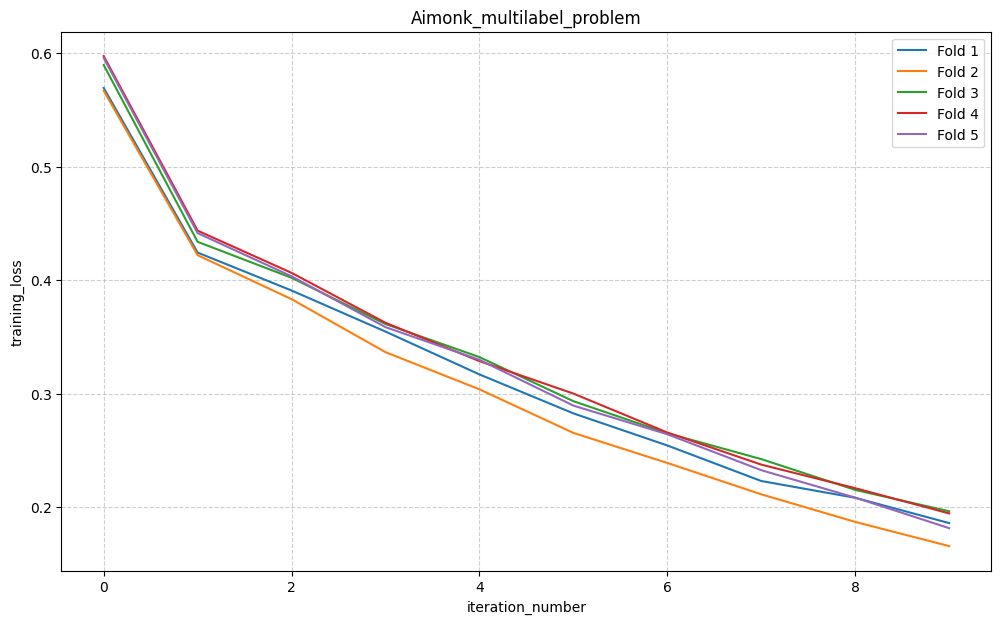

In [34]:
plot_all_fold_histories(all_histories)